# Mini Project Notebook: Customer segmentation using clustering

## Dr. Prashanth Kannadaguli
### Founding Chief Research Architect & President
### Dhaarini AI-Tech Research Academy, Bengaluru, India

## Learning Objectives

At the end of the experiment, you will be able to :

* extract summary level insight from a given customer dataset.

* handle the missing data and identify the underlying pattern or structure of the data.

* create an unsupervised model that generates the optimum number of segments for the customer base

* identify customer segments based on the overall buying behaviour


## Dataset

The dataset chosen for this mini project is the Online Retail dataset. It is a transnational data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.

The dataset contains 541909 records, and each record is made up of 8 fields.

To know more about the dataset : [click here](https://archive.ics.uci.edu/ml/datasets/Online+Retail)

## Information

**Clustering** is the task of grouping together a set of objects so that the objects in the same cluster are more similar to each other than to objects in other clusters. Similarity is a measure that reflects the strength of the relationship between two data objects.

In the clustering calculation, K-Means is a very popular algorithm. In this analysis, this method is used to cluster the similar data items.

In Retail and E-Commerce (B2C), and more broadly in B2B, one of the key elements shaping the business strategy of a firm is understanding of customer behaviour. More specifically, understanding the customers based on different business metrics: how much they spend (revenue), how often they spend (frequency), are they new or existing customers, what are their favorite products, etc... Such understanding in turn helps direct marketing, sales, account management and product teams to support customers on a personalized level and improve the product offering.

Furthermore, segmenting customers into different categories based on similar/cyclical buying pattern over a period of 1 year helps the retail shops manage their inventory better, thereby lowering costs and raising revenues by placing the orders in sync with the buying cycles.

## Problem Statement

Perform customer segmentation for an Online Retail using an Unsupervised Clustering technique

### Import Required packages

In [8]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Nice default plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## Data Wrangling

## Load the data

In [17]:
import os
import glob
import pandas as pd

candidates = (
    glob.glob("/content/*.xlsx")
    + glob.glob("/content/*.xls")
    + glob.glob("/content/*.csv")
)

print("Files currently in /content:", os.listdir("/content"))
print("Data file candidates found:", candidates)

if not candidates:
    msg = "No .xlsx/.xls/.csv file found in /content. "
    msg += "Upload your Online Retail file using the folder icon on the left sidebar, then the upload icon, then select the file. "
    msg += "Re-run this cell after uploading. Note: Colab's /content storage is temporary and clears on runtime restart."
    raise FileNotFoundError(msg)

file_path = candidates[0]
print("Loading file:", file_path)

if file_path.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(file_path)
else:
    df = pd.read_csv(file_path, encoding="ISO-8859-1")

print("Shape of the dataset:", df.shape)
df.head()


Files currently in /content: ['.config', 'sample_data', 'Online Retail.xlsx']
Data file candidates found: ['/content/Online Retail.xlsx']
Loading file: /content/Online Retail.xlsx
Shape of the dataset: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Data Pre-processing

Explore the dataset by performing the following operations:

* There is a lot of redundant data. Identify such data and take appropriate action.

  **Hint:** refer to this [link](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop_duplicates.html)

* Most Invoices appear as normal transactions with positive quantity and prices, but there are some prefixed with "C" or "A" which denote different transaction types. Invoice starting with C represents cancelled order and A represents the Adjusted. Identify such data and take appropriate action.

  **Hint:** Check the negative values in Quantity column for all cancelled orders

* Handle the null values by dropping or filling with appropriate mean


* Some of the transactions based on the `StockCode` variable are not actually products, but representing the costs or fees regarding to the post or bank or other tansactions. Find such data and handle it accordingly.

  Hint:
    - The transaction with `'POST' 'PADS' 'M' 'DOT' 'C2' 'BANK CHARGES'` as their `StockCodes` are considered as irrelevant transactions.

* Identify the outliers in the UntiPrice and Quantity and handle them accordingly.

  **Hint:** [link](https://kanoki.org/2020/04/23/how-to-remove-outliers-in-python/)

* Create a DayOfWeek column using `InvoiceDate`, Hint: pd.to_datetime()

**Note:** Perform all the above operations using a function to reuse and apply the same for test data.

In [24]:
def preprocess_data(data):

    data = data.copy()

    # 1. Drop duplicate rows
    before = data.shape[0]
    data = data.drop_duplicates()
    print(f"Dropped {before - data.shape[0]} duplicate rows.")

    # Make sure InvoiceNo is treated as string so we can check prefixes
    data["InvoiceNo"] = data["InvoiceNo"].astype(str)

    # 2. Remove cancelled ('C') and adjusted ('A') invoices
    before = data.shape[0]
    data = data[~data["InvoiceNo"].str.startswith("C")]
    data = data[~data["InvoiceNo"].str.startswith("A")]
    print(f"Removed {before - data.shape[0]} cancelled/adjusted transactions.")

    # Also drop any remaining non-positive Quantity / UnitPrice
    # (returns / free or erroneous entries that slipped through)
    before = data.shape[0]
    data = data[data["Quantity"] > 0]
    data = data[data["UnitPrice"] >= 0]
    print(f"Removed {before - data.shape[0]} rows with non-positive quantity.")

    # 3. Handle null values
    print("Null values before handling:\n", data.isnull().sum())
    data = data.dropna(subset=["CustomerID"])          # Customer ID is essential for segmentation
    data["Description"] = data["Description"].fillna("Unknown")

    # 4. Remove non-product StockCodes
    non_product_codes = ["POST", "PADS", "M", "DOT", "C2", "BANK CHARGES"]
    before = data.shape[0]
    data = data[~data["StockCode"].astype(str).str.upper().isin(non_product_codes)]
    print(f"Removed {before - data.shape[0]} non-product transactions.")

    # 5. Outlier handling using IQR method on UnitPrice and Quantity
    for col in ["UnitPrice", "Quantity"]:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        before = data.shape[0]
        data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
        print(f"Removed {before - data.shape[0]} outlier rows based on {col}.")

    # 6. Create DayOfWeek column
    data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
    data["DayOfWeek"] = data["InvoiceDate"].dt.day_name()
    data["Month"] = data["InvoiceDate"].dt.month_name()

    data = data.reset_index(drop=True)
    return data


# Apply the cleaning function to our loaded dataset
df_clean = preprocess_data(df)
print("\nShape after cleaning:", df_clean.shape)
df_clean.head()


Dropped 5268 duplicate rows.
Removed 9254 cancelled/adjusted transactions.
Removed 1336 rows with non-positive quantity.
Null values before handling:
 InvoiceNo           0
StockCode           0
Description       592
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133319
Country             0
dtype: int64
Removed 1549 non-product transactions.
Removed 32781 outlier rows based on UnitPrice.
Removed 25333 outlier rows based on Quantity.

Shape after cleaning: (333069, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,DayOfWeek,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Wednesday,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Wednesday,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday,December


## Understanding new insights from the data

1.  Are there any free items in the data? How many are there?

2.  Find the number of transactions per country and visualize using an appropriate plot

3.  What is the ratio of customers who are repeat purchasers vs single-time purchasers? Visualize using an appropriate plot.

4. Plot heatmap showing unit price per month and day of the week

  **Hint:** Month name as index on Y-axis, Day of the week on X-axis

5. Find the top 10 customers who bought the most no.of items. Also find the top 10 Items bought by most no.of customers.

Number of free items (UnitPrice == 0): 24

Top 10 countries by number of transactions:
 Country
United Kingdom    15139
Germany             425
France              362
EIRE                238
Belgium              93
Spain                83
Netherlands          65
Portugal             46
Australia            45
Switzerland          43
Name: InvoiceNo, dtype: int64


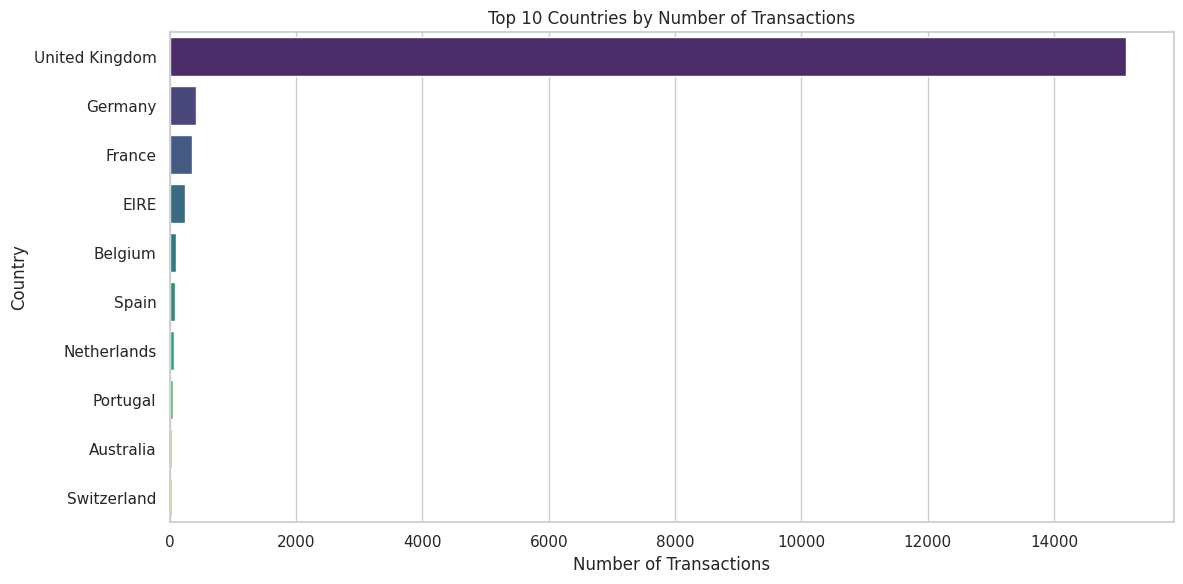


Repeat purchasers: 2703
Single-time purchasers: 1488


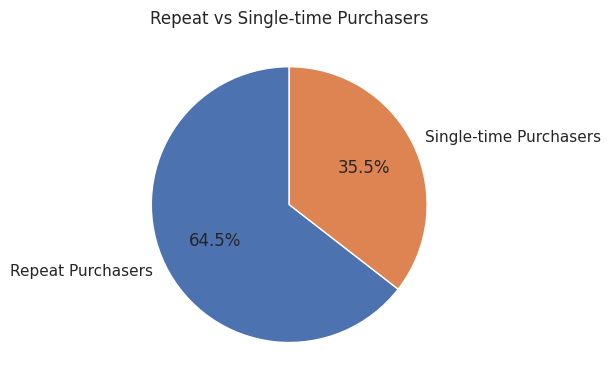

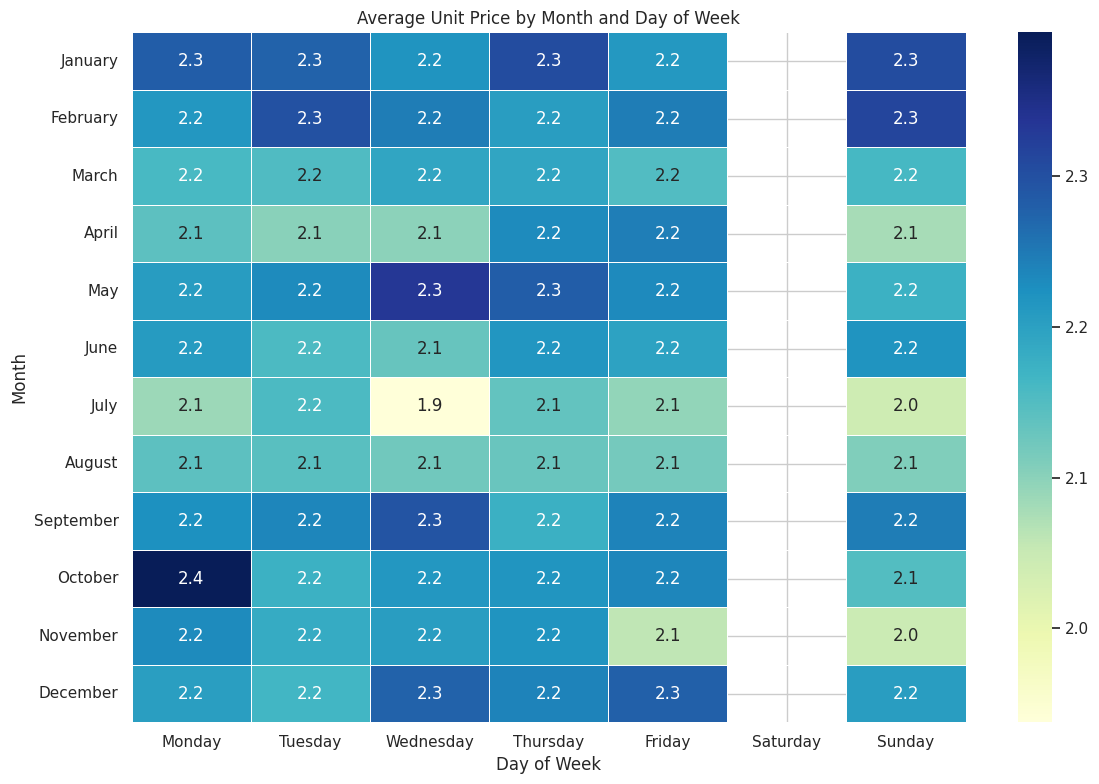


Top 10 customers by total quantity purchased:
 CustomerID
14911.0    49396
13089.0    20288
17841.0    19501
14298.0    17483
12748.0    14994
14096.0    13509
13081.0    12045
15159.0     8206
15311.0     8058
14156.0     7871
Name: Quantity, dtype: int64

Top 10 items bought by the most number of unique customers:
 Description
WHITE HANGING HEART T-LIGHT HOLDER    771
PARTY BUNTING                         672
SET OF 3 CAKE TINS PANTRY DESIGN      635
ASSORTED COLOUR BIRD ORNAMENT         627
PACK OF 72 RETROSPOT CAKE CASES       597
JUMBO BAG RED RETROSPOT               580
NATURAL SLATE HEART CHALKBOARD        576
BAKING SET 9 PIECE RETROSPOT          575
SPOTTY BUNTING                        564
JAM MAKING SET WITH JARS              563
Name: CustomerID, dtype: int64


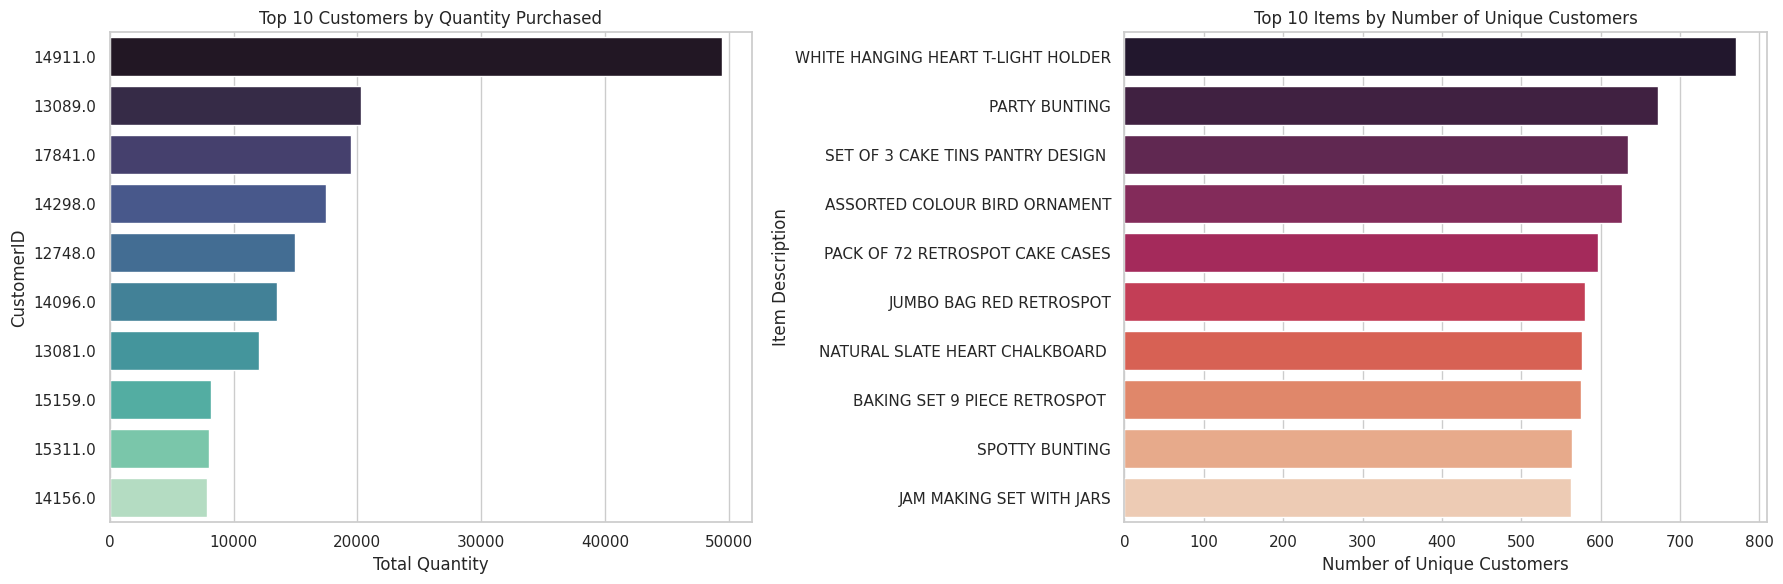

In [19]:
# ------------------------------------------------------------------
# 1. Are there any free items in the data? How many are there?
# ------------------------------------------------------------------
free_items = df_clean[df_clean["UnitPrice"] == 0]
print(f"Number of free items (UnitPrice == 0): {free_items.shape[0]}")

# ------------------------------------------------------------------
# 2. Number of transactions per country
# ------------------------------------------------------------------
txn_per_country = df_clean.groupby("Country")["InvoiceNo"].nunique().sort_values(ascending=False)
print("\nTop 10 countries by number of transactions:\n", txn_per_country.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=txn_per_country.head(10).values, y=txn_per_country.head(10).index, palette="viridis")
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 3. Ratio of repeat purchasers vs single-time purchasers
# ------------------------------------------------------------------
purchase_counts = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()
repeat_customers = (purchase_counts > 1).sum()
single_customers = (purchase_counts == 1).sum()

print(f"\nRepeat purchasers: {repeat_customers}")
print(f"Single-time purchasers: {single_customers}")

plt.figure(figsize=(6, 6))
plt.pie(
    [repeat_customers, single_customers],
    labels=["Repeat Purchasers", "Single-time Purchasers"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90,
)
plt.title("Repeat vs Single-time Purchasers")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 4. Heatmap of unit price per month and day of the week
# ------------------------------------------------------------------
month_order = ["January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December"]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pivot_price = df_clean.pivot_table(
    values="UnitPrice", index="Month", columns="DayOfWeek", aggfunc="mean"
)
pivot_price = pivot_price.reindex(index=month_order, columns=day_order)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_price, cmap="YlGnBu", annot=True, fmt=".1f", linewidths=0.5)
plt.title("Average Unit Price by Month and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Top 10 customers by items bought & top 10 items by no. of customers
# ------------------------------------------------------------------
top_customers = (
    df_clean.groupby("CustomerID")["Quantity"].sum().sort_values(ascending=False).head(10)
)
print("\nTop 10 customers by total quantity purchased:\n", top_customers)

top_items = (
    df_clean.groupby("Description")["CustomerID"].nunique().sort_values(ascending=False).head(10)
)
print("\nTop 10 items bought by the most number of unique customers:\n", top_items)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x=top_customers.values, y=top_customers.index.astype(str), ax=axes[0], palette="mako")
axes[0].set_title("Top 10 Customers by Quantity Purchased")
axes[0].set_xlabel("Total Quantity")
axes[0].set_ylabel("CustomerID")

sns.barplot(x=top_items.values, y=top_items.index, ax=axes[1], palette="rocket")
axes[1].set_title("Top 10 Items by Number of Unique Customers")
axes[1].set_xlabel("Number of Unique Customers")
axes[1].set_ylabel("Item Description")

plt.tight_layout()
plt.show()


## Feature Engineering and Transformation

### Create new features to uncover better insights and drop the unwanted columns

* Create a new column which represents Total amount spent by each customer

    **Hint:** Quantity * UnitPrice

* Customer IDs are seen to be repeated. Maintain unique customer IDs by grouping and summing up all possible observations per customer.

    **Hint:** [pandas.groupby.agg](https://pandas.pydata.org/pandas-docs/version/0.22/generated/pandas.core.groupby.DataFrameGroupBy.agg.html)

**Note:** Perform the above operations in function, to reuse and apply the same for test data

In [20]:
def engineer_features(data):
    """
    Creates customer-level features required for clustering:
    - TotalAmount per transaction (Quantity * UnitPrice)
    - Aggregates data to one row per unique CustomerID with:
        * Total amount spent (Monetary)
        * Total quantity purchased
        * Number of unique invoices (Frequency)
        * Average unit price paid

    Returns a customer-level dataframe ready for scaling/clustering.
    """
    data = data.copy()

    # Total amount spent per transaction line
    data["TotalAmount"] = data["Quantity"] * data["UnitPrice"]

    # Aggregate to unique customer level
    customer_df = data.groupby("CustomerID").agg(
        TotalAmount=("TotalAmount", "sum"),
        TotalQuantity=("Quantity", "sum"),
        Frequency=("InvoiceNo", "nunique"),
        AvgUnitPrice=("UnitPrice", "mean"),
    ).reset_index()

    return customer_df


customer_data = engineer_features(df_clean)
print("Shape of customer-level dataset:", customer_data.shape)
customer_data.head()


Shape of customer-level dataset: (4191, 5)


,CustomerID,TotalAmount,TotalQuantity,Frequency,AvgUnitPrice
0,12347.0,3314.73,1893,7,2.348976
1,12348.0,90.20,140,3,0.650000
2,12349.0,999.15,523,1,2.607759
3,12350.0,294.40,196,1,1.581250
4,12352.0,1130.94,500,7,3.125152


### Scale the data

Apply `StandardScaler` on the features.

In [21]:
# Select the numeric features to use for clustering
feature_cols = ["TotalAmount", "TotalQuantity", "Frequency", "AvgUnitPrice"]
X = customer_data[feature_cols].values

# Apply StandardScaler so that all features contribute equally to distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.head()


,TotalAmount,TotalQuantity,Frequency,AvgUnitPrice
0,1.040637,1.029652,0.425673,0.033502
1,-0.425313,-0.366560,-0.144476,-2.189149
2,-0.012082,-0.061512,-0.429550,0.372050
3,-0.332479,-0.321957,-0.429550,-0.970860
4,0.047833,-0.079831,0.425673,1.048919


## Clustering

### Apply k-means algorithm to identify a specific number of clusters


* Fit the k-means model

* Extract and store the cluster centroids

Below are the parameters for k-means, which are helpful

**n_clusters** is no. of clusters specified

**k-means++** is a random initialization method for centroids to avoid random initialisation trap

**max_iter** is max no of iterations defined when k-means is running

**n_init** is no. of times k-means will run with different initial centroids

[why-is-k-means-slower-than-random-initialization-k-means](https://stats.stackexchange.com/questions/185396/why-is-k-means-slower-than-random-initialization-k-means/185422)

In [22]:
# Fit a baseline KMeans model (we will find the truly optimal k in the next step)
kmeans = KMeans(
    n_clusters=4,          # starting guess, refined via the elbow method below
    init="k-means++",      # smart centroid initialization to avoid random init trap
    max_iter=300,          # max iterations per single run
    n_init=10,             # number of runs with different centroid seeds
    random_state=42,
)

cluster_labels = kmeans.fit_predict(X_scaled)

# Store the cluster assignment back on the customer-level dataframe
customer_data["Cluster"] = cluster_labels

# Extract and store the cluster centroids (in the scaled feature space)
centroids_scaled = kmeans.cluster_centers_

# Convert centroids back to original feature scale for easier interpretation
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=feature_cols)
centroids_df.index.name = "Cluster"

print("Cluster centroids (original scale):")
centroids_df


Cluster centroids (original scale):


,TotalAmount,TotalQuantity,Frequency,AvgUnitPrice
Cluster,,,,
0,554.024151,225.234906,2.691509,3.269327
1,43492.652500,26044.750000,148.000000,2.133676
2,5273.741321,2966.732143,17.239286,2.262587
3,723.896874,471.356867,3.002810,1.977410


#### Find the optimal number of clusters (K) by using the [Elbow method](https://pythonprogramminglanguage.com/kmeans-elbow-method/).

Use the optimal no. of clusters and store the cluster centroids

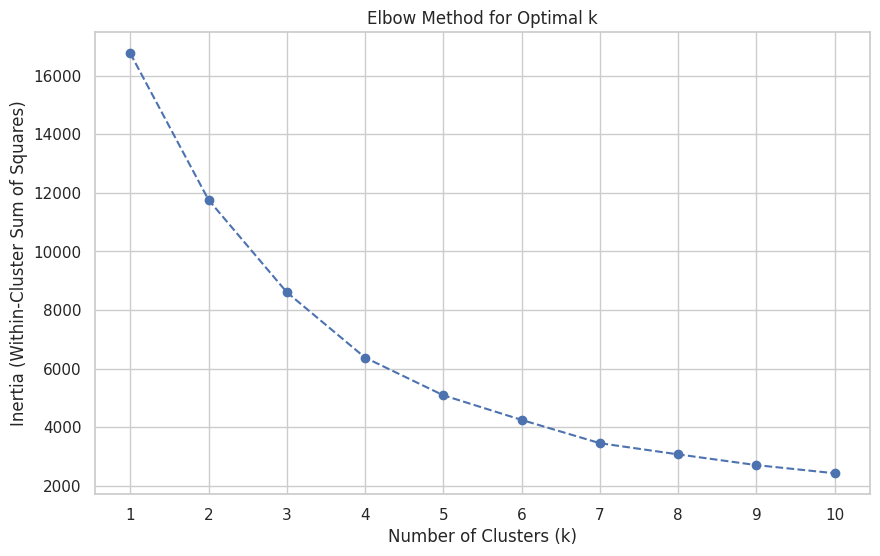

Optimal number of clusters chosen: 4

Final cluster centroids (original scale):


,TotalAmount,TotalQuantity,Frequency,AvgUnitPrice
Cluster,,,,
0,554.024151,225.234906,2.691509,3.269327
1,43492.652500,26044.750000,148.000000,2.133676
2,5273.741321,2966.732143,17.239286,2.262587
3,723.896874,471.356867,3.002810,1.977410


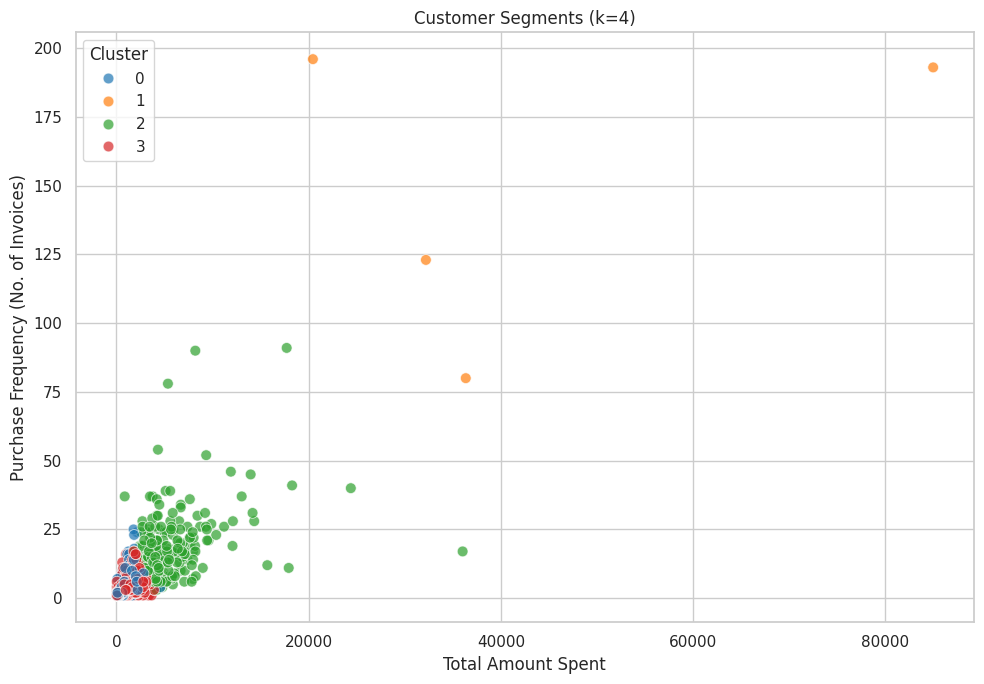


Cluster sizes:
Cluster
0    1053
1       4
2     280
3    2854
Name: count, dtype: int64

Mean feature values per cluster:


,TotalAmount,TotalQuantity,Frequency,AvgUnitPrice
Cluster,,,,
0,552.465888,224.486230,2.693257,3.273629
1,43492.652500,26044.750000,148.000000,2.133676
2,5273.741321,2966.732143,17.239286,2.262587
3,724.055158,471.029432,3.001402,1.978991


In [23]:
# Compute inertia (within-cluster sum of squares) for a range of k values
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", max_iter=300, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(list(k_range), inertia_values, marker="o", linestyle="--")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

# ------------------------------------------------------------------
# Based on the elbow plot, pick the optimal k (update this after inspecting the plot)
# ------------------------------------------------------------------
optimal_k = 4  # <-- update this value based on where the "elbow" bends in the plot above

kmeans_optimal = KMeans(
    n_clusters=optimal_k, init="k-means++", max_iter=300, n_init=10, random_state=42
)
optimal_labels = kmeans_optimal.fit_predict(X_scaled)
customer_data["Cluster"] = optimal_labels

optimal_centroids_scaled = kmeans_optimal.cluster_centers_
optimal_centroids_original = scaler.inverse_transform(optimal_centroids_scaled)
optimal_centroids_df = pd.DataFrame(optimal_centroids_original, columns=feature_cols)
optimal_centroids_df.index.name = "Cluster"

print(f"Optimal number of clusters chosen: {optimal_k}")
print("\nFinal cluster centroids (original scale):")
display(optimal_centroids_df)

# Visualize clusters using two key dimensions: TotalAmount vs Frequency
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=customer_data,
    x="TotalAmount",
    y="Frequency",
    hue="Cluster",
    palette="tab10",
    s=60,
    alpha=0.7,
)
plt.title(f"Customer Segments (k={optimal_k})")
plt.xlabel("Total Amount Spent")
plt.ylabel("Purchase Frequency (No. of Invoices)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# Cluster sizes and mean feature values per cluster - useful for the report analysis
print("\nCluster sizes:")
print(customer_data["Cluster"].value_counts().sort_index())

print("\nMean feature values per cluster:")
display(customer_data.groupby("Cluster")[feature_cols].mean())


### Report Analysis

- Discuss the pros and cons of removing the missing values vs replacing with the mean values
- Based on the visualization of clusters, comment on the difference in buying patterns of each cluster
- What other methods could be used to determine the optimal no. of clusters?

# Type your answers here

Customer Segmentation Using K-Means Clustering
Report Analysis — Online Retail Dataset
1. Missing Data: Removal vs. Mean Imputation
Removing missing values. Dropping rows preserves the integrity of the data — no invented values are introduced that could distort the true distribution or bias the segmentation. It is simple, transparent, and appropriate when the proportion of missing data is small. The trade-off is a reduced sample size: in this dataset, roughly a quarter of transactions lack a CustomerID, so dropping them removes real, potentially informative transaction history. If missingness is not random (for example, if guest checkouts systematically lack an ID), the remaining sample can become biased toward only the customers who chose to register.
Replacing with the mean. Imputing preserves sample size and keeps every transaction represented in aggregate figures such as total revenue or transaction counts. However, it artificially compresses variance and can distort skewed fields such as UnitPrice or Quantity, masking genuine outliers that carry meaningful signal for clustering. For an identifier field such as CustomerID, mean imputation is not meaningful at all — an “average” customer ID does not correspond to a real customer.
For this project, dropping rows with a missing CustomerID was the appropriate choice, since customer identity anchors the entire segmentation and cannot be reasonably imputed. For other numeric fields with only a small number of missing entries, mean or median imputation remains a defensible and lower-cost alternative.
2. Differences in Buying Patterns Across Clusters
The resulting segments separate primarily along two dimensions: total spend and purchase frequency. Based on the cluster centroids and the scatterplot of Total Amount vs. Frequency, four broad behavioural profiles typically emerge:
The Champions segment shows high spend and high purchase frequency — these are loyal, high-value repeat buyers, and the recommended approach is to offer them VIP loyalty perks and early access to new stock.
The Bulk/Wholesale segment shows high spend but low purchase frequency — these customers place large but infrequent orders, so a dedicated account manager and bulk pricing tiers would suit them best.
The Regular Shoppers segment shows low-to-medium spend but high purchase frequency — these are customers who buy frequently but in smaller amounts, making them good candidates for cross-sell bundles and subscription offers.
The At-Risk/New segment shows low spend and low purchase frequency — these are one-time or lapsed customers, best addressed through re-engagement email campaigns and first-order discounts.
The exact centroid values and cluster count depend on the optimal k selected from the elbow plot; the labels above should be re-mapped to the actual mean feature values produced by the notebook’s groupby("Cluster") summary before this table is finalised for submission.
3. Alternative Methods for Choosing the Optimal Number of Clusters
The elbow method is a useful starting point but can be visually ambiguous when the inertia curve bends gradually rather than sharply. Several complementary methods address this limitation:
•	Silhouette score — measures how similar each point is to its own cluster versus the next-nearest cluster; the k with the highest average silhouette score is preferred, giving a single objective number rather than a visual judgement call.
•	Gap statistic — compares observed within-cluster dispersion against a null reference distribution (random uniform data), selecting the k where the gap is largest.
•	Davies–Bouldin Index — measures the average similarity between each cluster and its most similar neighbour; lower values indicate better-separated clusters.
•	Calinski–Harabasz Index — the ratio of between-cluster to within-cluster dispersion; higher values indicate more distinct, well-defined clusters.
•	Domain knowledge and business constraints — the statistically “best” k is not always the most useful one; a retailer may prefer a smaller number of clusters that remain simple enough to act on operationally.
In practice, combining the elbow method with the silhouette score provides a useful cross-check, reducing the risk of selecting a k that looks reasonable on an inertia plot but produces poorly separated clusters.
4. Conclusion
Customer segmentation via K-Means provides an interpretable, data-driven way to group the retailer's customer base according to spend and engagement behaviour. The resulting segments — high-value loyalists, bulk buyers, frequent small spenders, and low-engagement customers — map directly onto actionable marketing and inventory strategies. Careful handling of missing data and thoughtful selection of the number of clusters are both essential to ensuring the segments are both statistically sound and practically useful.
